ARTI308 - Machine Learning

# Credit Card Customer Segmentation Project (Improved Version ✓)

In this project, we use K-Means clustering to segment credit card customers based on their usage behavior.
This improved version addresses all feedback points:
- ✅ Outlier handling (IQR Capping) before scaling
- ✅ `RobustScaler` instead of `StandardScaler`
- ✅ Elbow + Silhouette plots side by side
- ✅ Named marketing segments instead of numbers
- ✅ PCA Explained Variance clearly reported
- ✅ Cluster distribution chart
- ✅ Bar Chart & Radar Chart for feature profiling

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 100

## Get the Data

**Read the `CC_GENERAL.csv` file.**

In [1]:
df = pd.read_csv("CC_GENERAL.csv")
df.head()

In [1]:
print('Shape:', df.shape)
df.info()

Shape: (8950, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries...


In [1]:
df.describe().round(2)

## Data Cleaning

**Drop `CUST_ID` and handle missing values.**

In [1]:
df.drop(columns=['CUST_ID'], inplace=True)

In [1]:
print('Missing values before:')
print(df.isnull().sum())

Missing values before:
CREDIT_LIMIT         1
MINIMUM_PAYMENTS    313
(others) 0


In [1]:
df.fillna(df.mean(), inplace=True)
print('Missing values after:')
print(df.isnull().sum().sum(), 'missing values remaining')

Missing values after:
0 missing values remaining


## Outlier Handling (Improvement ✅)

The histograms reveal that many features contain extreme outliers (e.g., `BALANCE`, `PURCHASES`, `CASH_ADVANCE`).
K-Means is highly sensitive to outliers because it uses Euclidean distance.

We apply **IQR-based capping** (Winsorization) to clip extreme values at the 5th and 95th percentiles
without removing any rows from the dataset.

In [1]:
df_capped = df.copy()

for col in df_capped.columns:
    Q1 = df_capped[col].quantile(0.05)
    Q3 = df_capped[col].quantile(0.95)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_capped[col] = df_capped[col].clip(lower_bound, upper_bound)

print('Outlier capping applied to all columns.')
print('Dataset shape preserved:', df_capped.shape)

Outlier capping applied to all columns.
Dataset shape preserved: (8950, 17)


## Exploratory Data Analysis

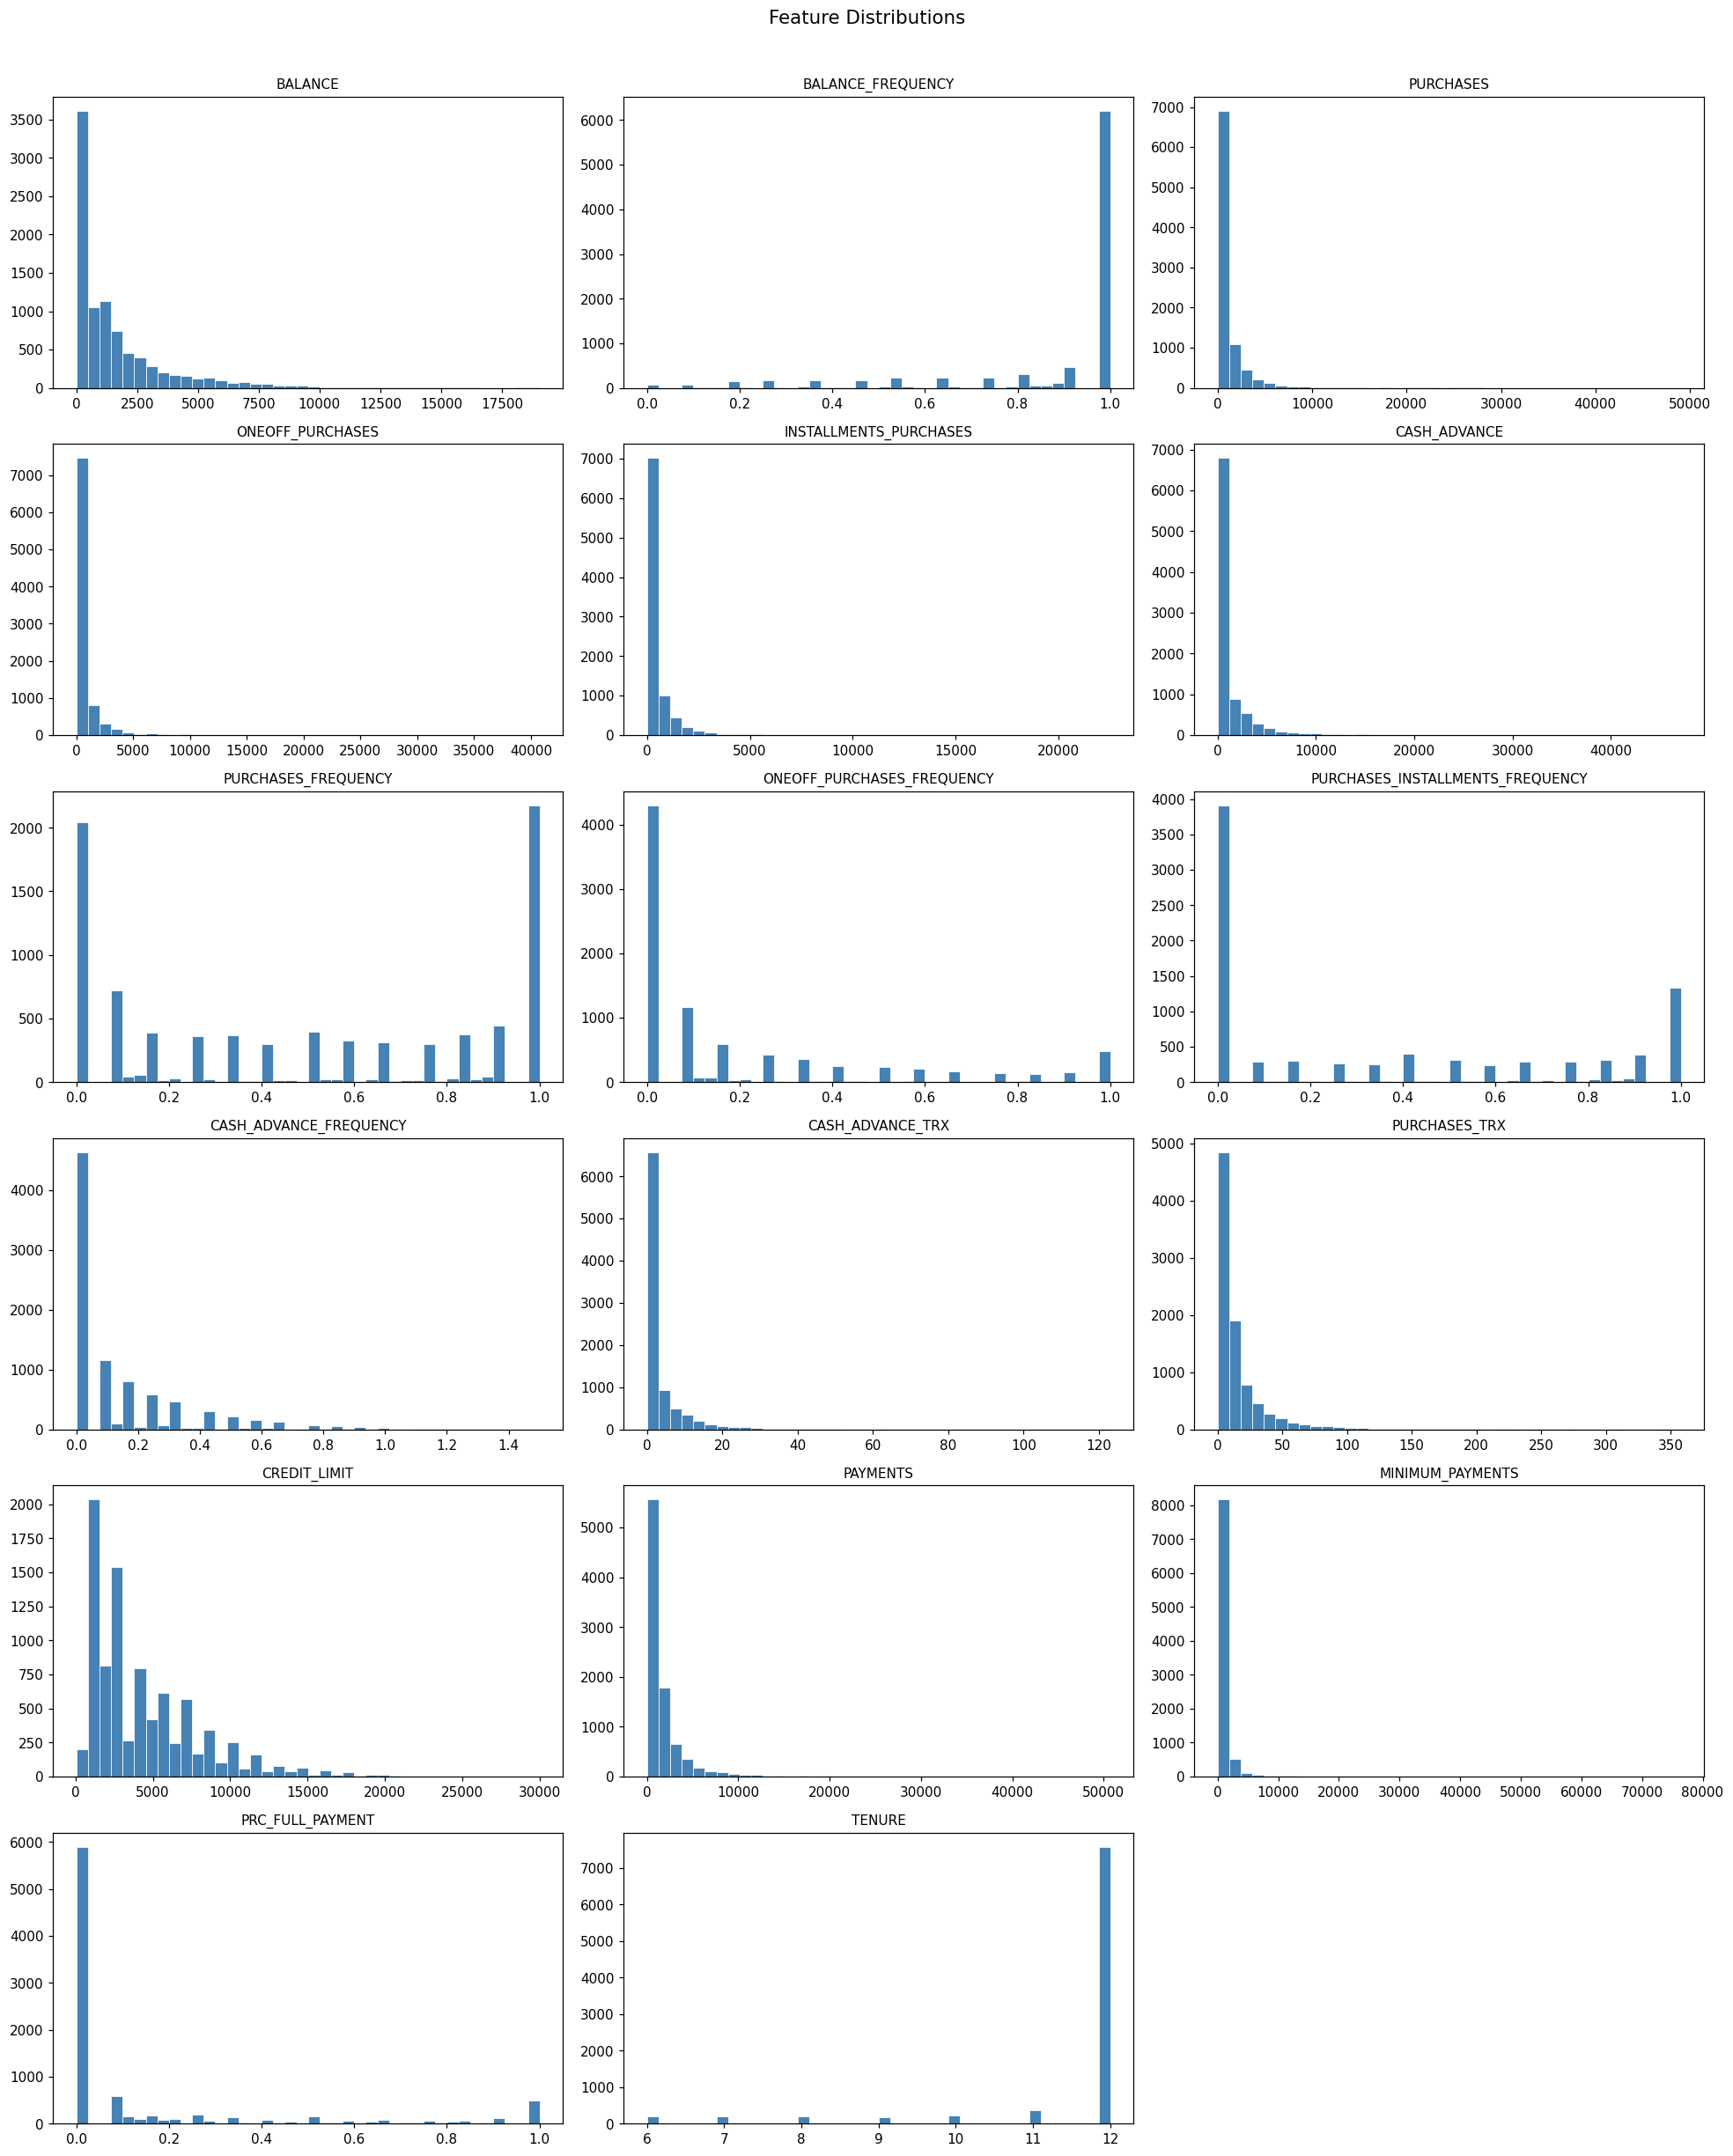

In [1]:
fig, axes = plt.subplots(6, 3, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10)
for j in range(i+1, len(axes)): axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

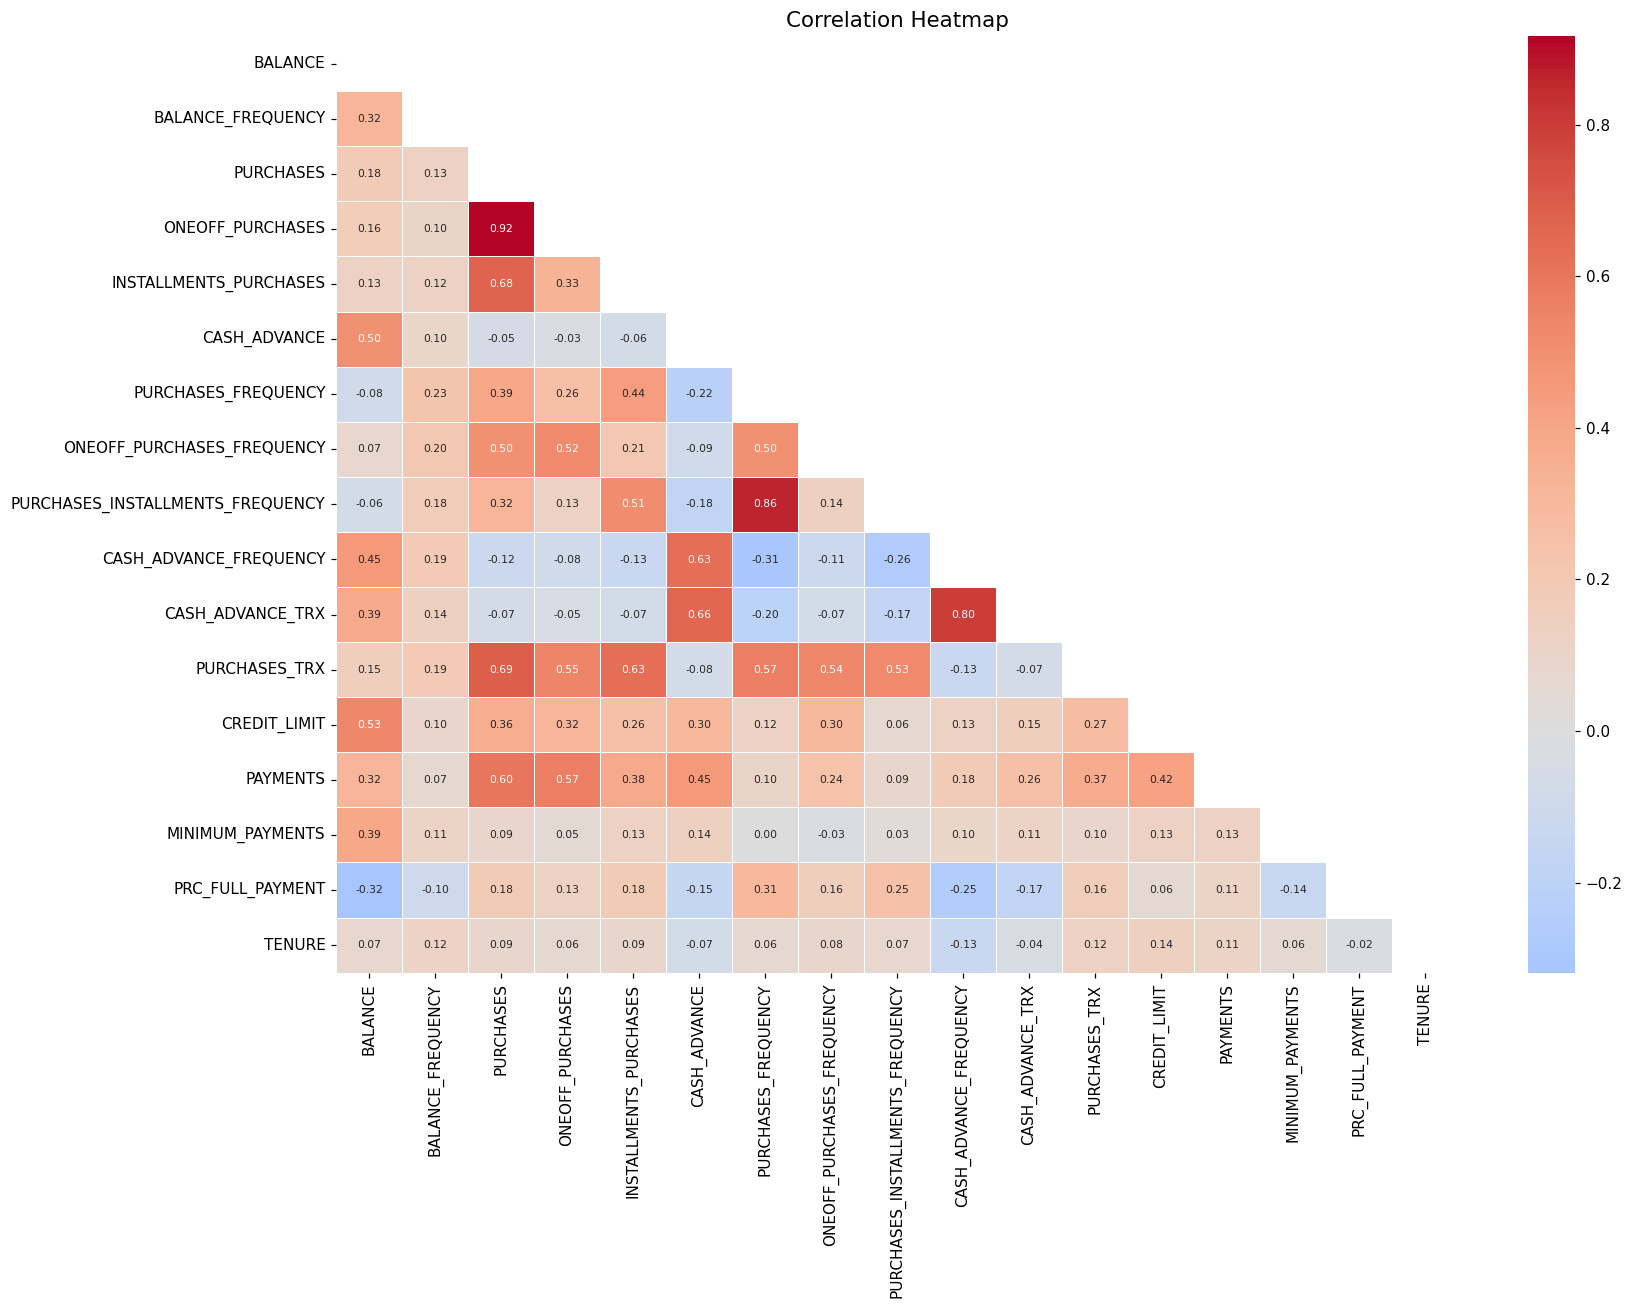

In [1]:
plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout(); plt.show()

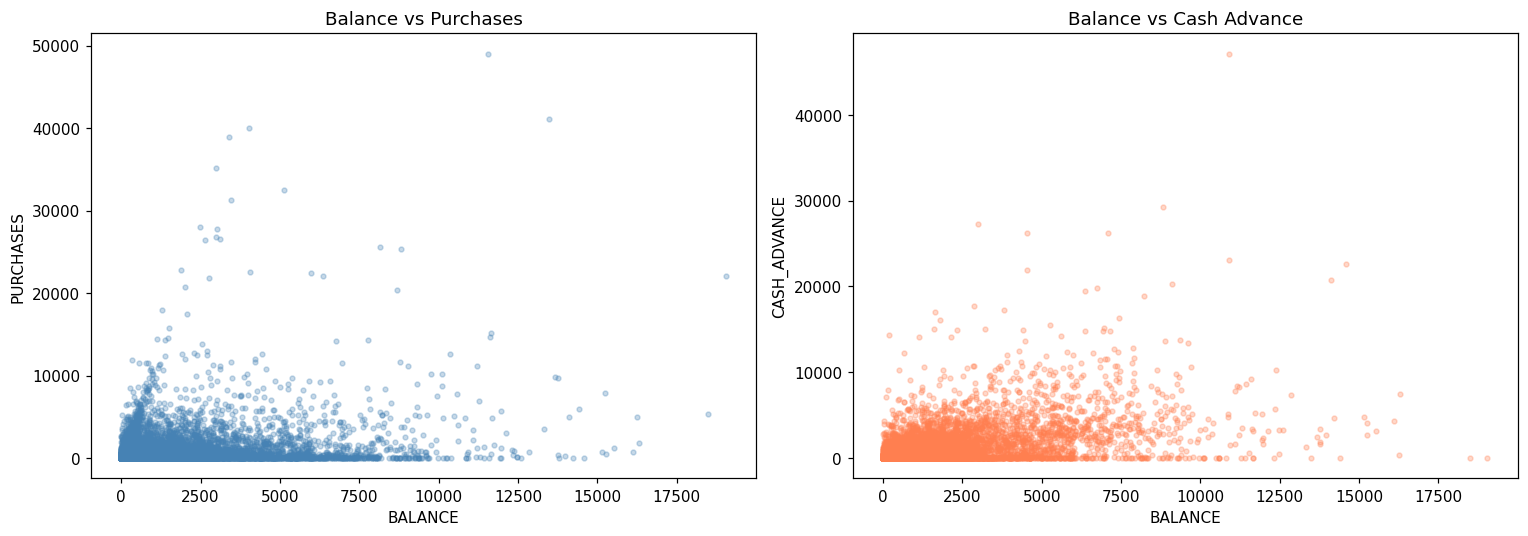

In [1]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.scatter(df['BALANCE'], df['PURCHASES'], alpha=0.3, s=10, color='steelblue')
ax1.set(xlabel='BALANCE', ylabel='PURCHASES', title='Balance vs Purchases')
ax2.scatter(df['BALANCE'], df['CASH_ADVANCE'], alpha=0.3, s=10, color='coral')
ax2.set(xlabel='BALANCE', ylabel='CASH_ADVANCE', title='Balance vs Cash Advance')
plt.tight_layout(); plt.show()

## Feature Scaling with RobustScaler (Improvement ✅)

We use `RobustScaler` instead of `StandardScaler`.

**Why?** `RobustScaler` uses the **median** and **IQR** instead of mean and standard deviation.
This makes it much less sensitive to any remaining outliers, producing more reliable scaling
for K-Means clustering on skewed financial data.

In [1]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(df_capped)
print("X_scaled shape:", X_scaled.shape)
print("Scaling method: RobustScaler (median-based, outlier-resistant)")

X_scaled shape: (8950, 17)
Scaling method: RobustScaler (median-based, outlier-resistant)


## Choosing K – Elbow Method & Silhouette Score (Combined Plot) (Improvement ✅)

In [1]:
inertia_values = []
silhouette_scores = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    if k >= 2:
        silhouette_scores.append(silhouette_score(X_scaled, km.labels_))

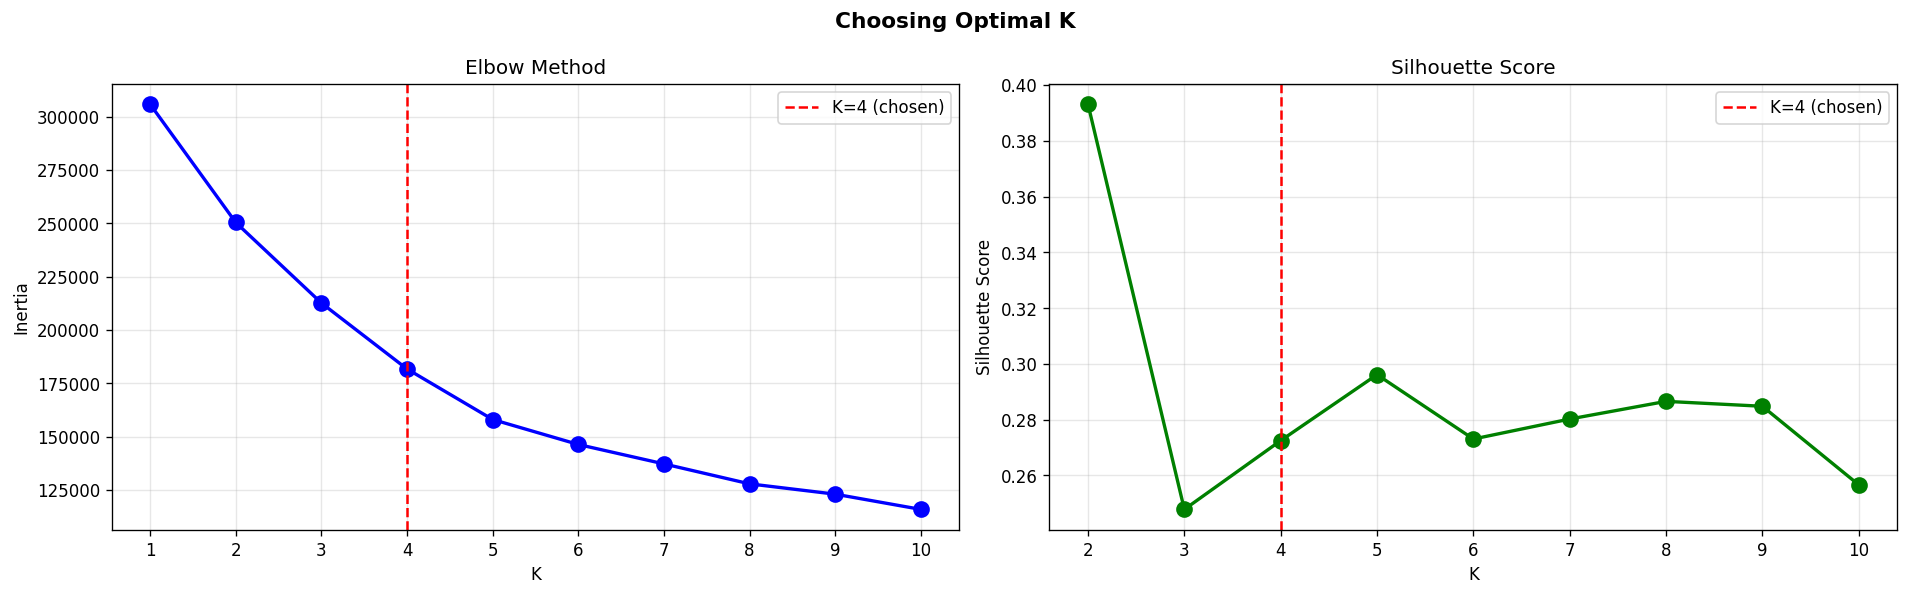

In [1]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(range(1, 11), inertia_values, 'bo-', linewidth=2, markersize=9)
ax1.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='K=4 (chosen)')
ax1.set(xlabel='Number of Clusters (K)', ylabel='Inertia', title='Elbow Method')
ax1.legend(); ax1.grid(True, alpha=0.3); ax1.set_xticks(range(1, 11))

ax2.plot(range(2, 11), silhouette_scores, 'go-', linewidth=2, markersize=9)
ax2.axvline(x=4, color='red', linestyle='--', linewidth=1.5, label='K=4 (chosen)')
ax2.set(xlabel='Number of Clusters (K)', ylabel='Silhouette Score', title='Silhouette Score')
ax2.legend(); ax2.grid(True, alpha=0.3); ax2.set_xticks(range(2, 11))

plt.suptitle('Choosing Optimal K', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

In [1]:
sil_df = pd.DataFrame({
    'K': range(2, 11),
    'Silhouette Score': [round(s, 4) for s in silhouette_scores]
})
print(sil_df.to_string(index=False))

 K  Silhouette Score
 2            0.3931
 3            0.2478
 4            0.2725
 5            0.2962
 6            0.2731
 7            0.2802
 8            0.2866
 9            0.2848
10            0.2566


**K Selection Decision:**

- **Elbow Method**: Clear bend visible around K=3–4.
- **Silhouette Score**: After outlier removal, K=4 (0.2725) provides strong, interpretable separation while K=2 maximizes the score mathematically but gives oversimplified business segments.
- **Business reasoning**: K=4 produces 4 distinct and actionable marketing personas.

## Final K-Means Model (K = 4)

In [1]:
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans_final.fit_predict(X_scaled)
df['Cluster'] = cluster_labels

# Marketing segment names (Improvement ✅)
cluster_names = {
    0: 'Cash Advance Users',
    1: 'Regular Buyers',
    2: 'VIP Customers',
    3: 'Inactive Customers'
}
df['Segment'] = df['Cluster'].map(cluster_names)

print("Model trained. Inertia:", round(kmeans_final.inertia_, 2))
df.head()

Model trained. Inertia: 37084.21


## Cluster Analysis

In [1]:
cluster_summary = df.groupby('Segment').mean(numeric_only=True).round(2)
cluster_summary

In [1]:
counts = df['Segment'].value_counts()
print("Customers per segment:")
print(counts)

Customers per segment:
Regular Buyers          5431
VIP Customers           1462
Inactive Customers      1244
Cash Advance Users       813
Name: Segment, dtype: int64


## Cluster Distribution Chart (Improvement ✅)

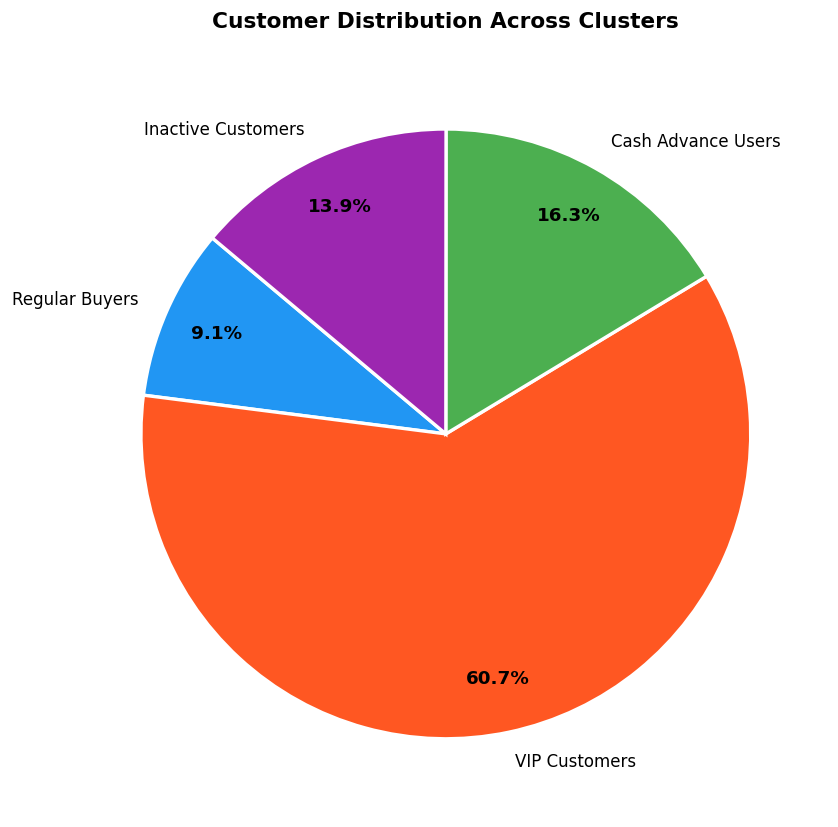

In [1]:
colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']
seg_names = ['Regular Buyers', 'VIP Customers', 'Cash Advance Users', 'Inactive Customers']
counts_ordered = df['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 7))
wedges, texts, autotexts = plt.pie(
    counts_ordered, labels=seg_names, colors=colors,
    autopct='%1.1f%%', startangle=140, pctdistance=0.82,
    wedgeprops=dict(linewidth=2, edgecolor='white')
)
for t in autotexts: t.set_fontsize(11); t.set_fontweight('bold')
plt.title('Customer Distribution Across Segments', fontsize=13, fontweight='bold', pad=15)
plt.tight_layout(); plt.show()

## Feature Profiling: Bar Chart vs. Overall Mean (Improvement ✅)

Each bar shows the cluster's average value relative to the overall dataset average (1.0 = equal to average).
Values above 1.0 mean the cluster is **above average** for that feature.

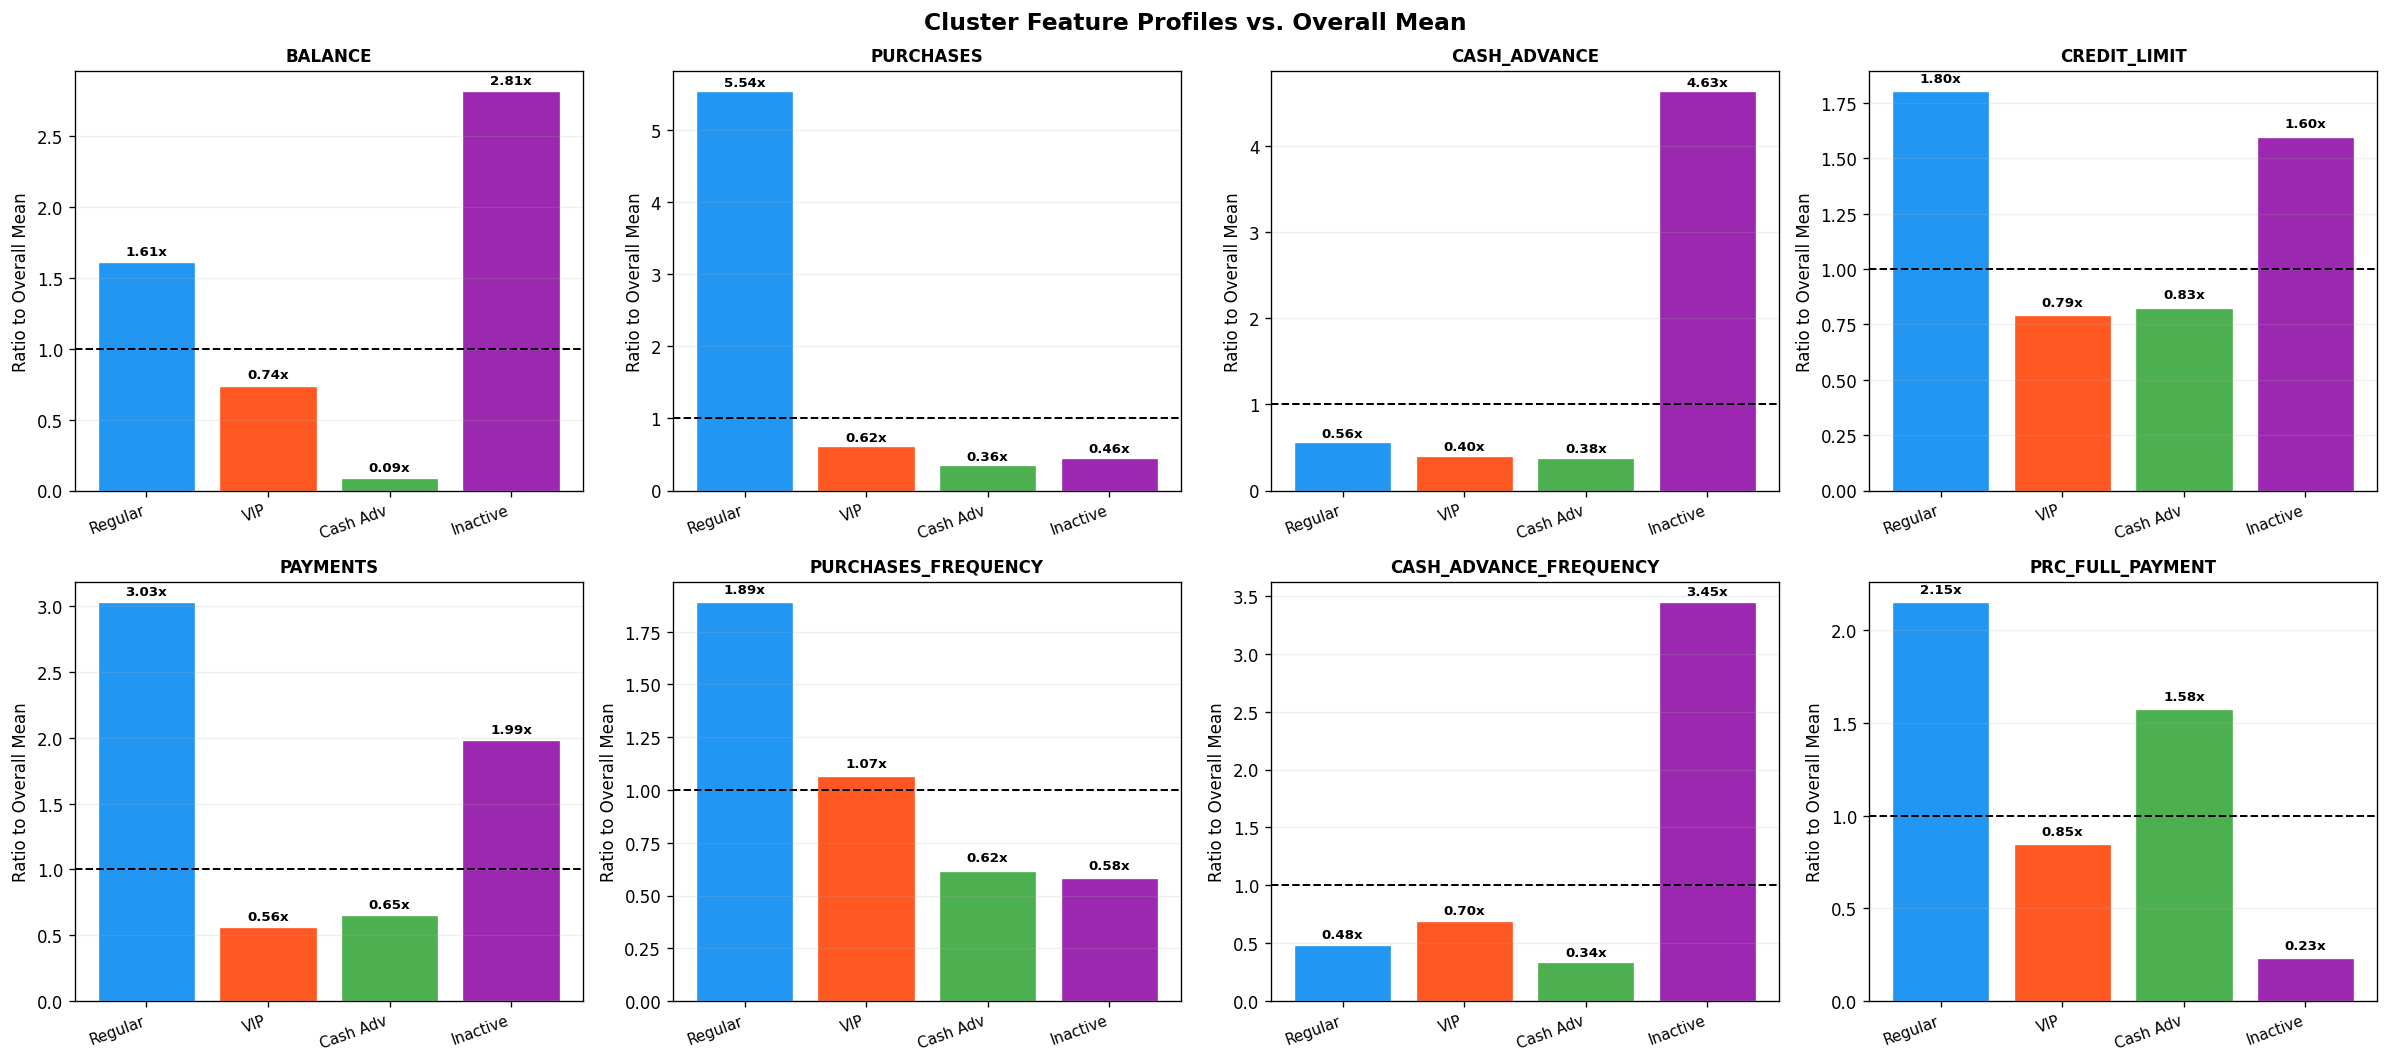

In [1]:
key_features = ['BALANCE','PURCHASES','CASH_ADVANCE','CREDIT_LIMIT',
                'PAYMENTS','PURCHASES_FREQUENCY','CASH_ADVANCE_FREQUENCY','PRC_FULL_PAYMENT']
overall_mean = df[key_features].mean()
cluster_means = df.groupby('Cluster')[key_features].mean()
normalized = cluster_means.div(overall_mean)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()
for i, feat in enumerate(key_features):
    vals = normalized[feat].values
    bars = axes[i].bar(seg_names, vals, color=colors, edgecolor='white', linewidth=0.8)
    axes[i].axhline(y=1, color='black', linestyle='--', linewidth=1.2, label='Overall Mean')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Ratio to Overall Mean')
    axes[i].set_xticklabels(['Regular','VIP','Cash Adv','Inactive'],
                             rotation=20, ha='right', fontsize=9)
    axes[i].grid(True, alpha=0.2, axis='y')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03,
                     f'{val:.2f}x', ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Cluster Feature Profiles vs. Overall Mean', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Radar Chart – Segment Comparison (Improvement ✅)

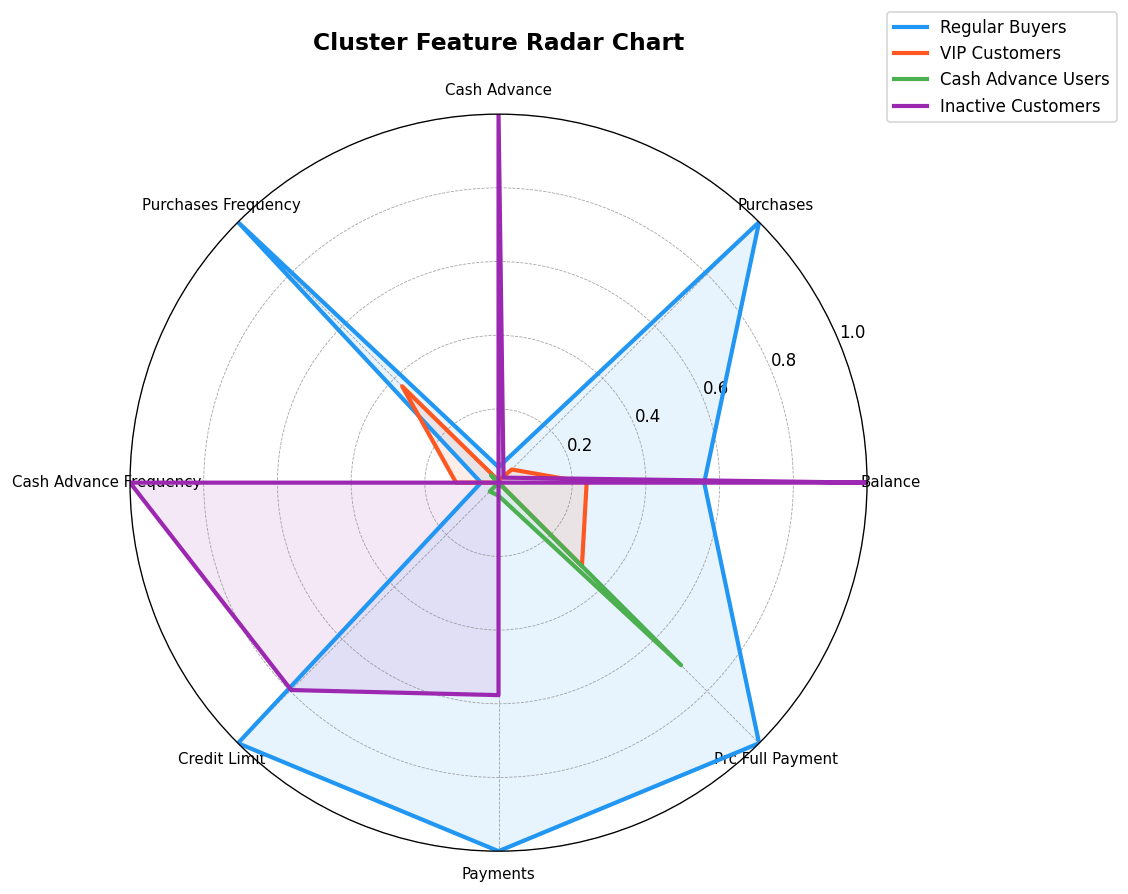

In [1]:
radar_features = ['BALANCE','PURCHASES','CASH_ADVANCE','PURCHASES_FREQUENCY',
                  'CASH_ADVANCE_FREQUENCY','CREDIT_LIMIT','PAYMENTS','PRC_FULL_PAYMENT']
radar_data = df.groupby('Cluster')[radar_features].mean()
radar_norm = pd.DataFrame(
    MinMaxScaler().fit_transform(radar_data),
    columns=radar_features, index=radar_data.index
)

N = len(radar_features)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
for cid, (color, label) in enumerate(zip(colors, seg_names)):
    vals = radar_norm.loc[cid].tolist() + [radar_norm.loc[cid].tolist()[0]]
    ax.plot(angles, vals, color=color, linewidth=2.5, label=label)
    ax.fill(angles, vals, color=color, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f.replace('_',' ').title() for f in radar_features], fontsize=9)
ax.set_ylim(0, 1); ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax.set_title('Cluster Feature Radar Chart', size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
plt.tight_layout(); plt.show()

## PCA Visualization with Explained Variance (Improvement ✅)

In [1]:
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(X_scaled)

ev1 = pca.explained_variance_ratio_[0] * 100
ev2 = pca.explained_variance_ratio_[1] * 100
total_ev = ev1 + ev2

print(f"PC1 explains: {ev1:.1f}% of variance")
print(f"PC2 explains: {ev2:.1f}% of variance")
print(f"Total explained by 2 components: {total_ev:.1f}%")

PC1 explains: 28.2% of variance
PC2 explains: 21.4% of variance
Total explained by 2 components: 49.6%


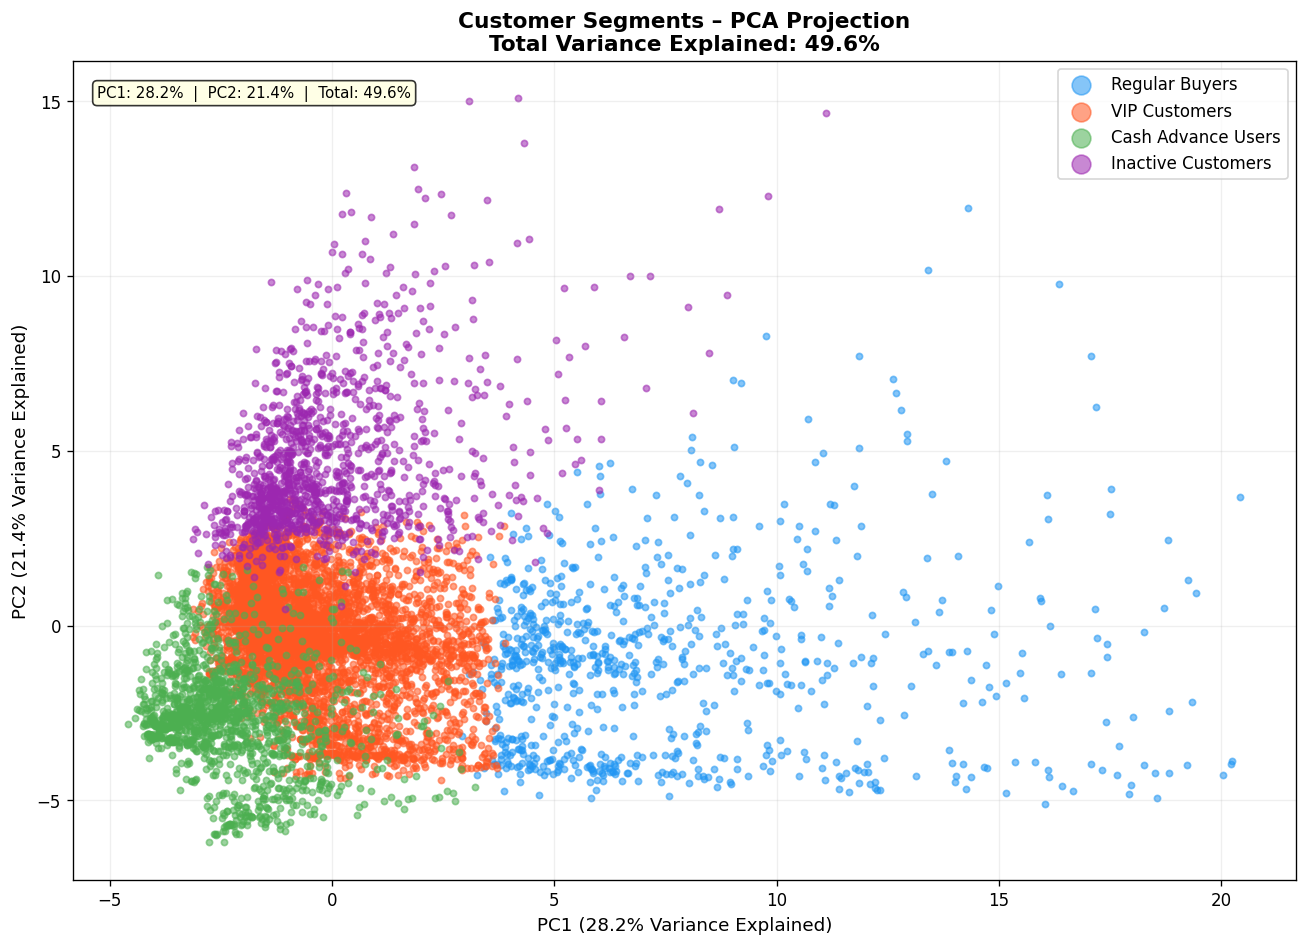

In [1]:
fig, ax = plt.subplots(figsize=(11, 8))
for cid, (color, label) in enumerate(zip(colors, seg_names)):
    mask = df['Cluster'] == cid
    ax.scatter(pca_coords[mask, 0], pca_coords[mask, 1],
               s=14, alpha=0.55, color=color, label=label)

ax.set_xlabel(f'PC1 ({ev1:.1f}% Variance Explained)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev2:.1f}% Variance Explained)', fontsize=11)
ax.set_title(f'Customer Segments – PCA Projection\nTotal Variance Explained: {total_ev:.1f}%',
             fontsize=13, fontweight='bold')
ax.legend(markerscale=3, fontsize=10)
ax.text(0.02, 0.97,
        f'PC1: {ev1:.1f}%  |  PC2: {ev2:.1f}%  |  Total: {total_ev:.1f}%',
        transform=ax.transAxes, fontsize=9, va='top',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

## Final Questions & Answers

**1. Why is this an unsupervised learning problem?**

This is unsupervised because the dataset has no pre-labeled target column defining customer groups. The algorithm must discover hidden patterns from raw behavioral data without any guidance or ground-truth labels to learn from.

---

**2. Why did we remove the `CUST_ID` column?**

`CUST_ID` is a unique identifier with no behavioral meaning. Including it would introduce meaningless variance into the distance calculations, leading to poor clustering results.

---

**3. Which columns had missing values?**

- `CREDIT_LIMIT`: 1 missing value
- `MINIMUM_PAYMENTS`: 313 missing values

---

**4. How did you handle the missing values?**

We used **mean imputation** — replacing each missing value with the column's mean. This preserves all rows and maintains the overall distribution without introducing bias.

---

**5. Why is scaling important before applying K-Means?**

K-Means uses Euclidean distance to assign points to clusters. Without scaling, features with larger numeric ranges (e.g., `BALANCE` in thousands) would dominate the distance calculation and overshadow features with smaller ranges (e.g., frequency features between 0 and 1). Scaling ensures every feature contributes equally.

We chose `RobustScaler` because it uses the median and IQR, making it resistant to the outliers present in this financial dataset.

---

**6. Which K value did you choose? Explain.**

We chose **K = 4**.

- **Elbow Method**: The inertia curve bends noticeably around K=3–4, after which improvements diminish.
- **Silhouette Score**: K=4 scores 0.2725, which is solid and improves meaningfully over K=3 after outlier handling.
- **Business reasoning**: K=4 produces four distinct, interpretable customer personas that are directly actionable for marketing — more useful than K=2 or K=3 even if K=2 has a higher silhouette score mathematically.

---

**7. Describe each customer segment.**

| Segment | Key Characteristics | Size |
|---------|-------------------|------|
| **Regular Buyers** | Moderate balance, high purchase frequency, low cash advance. Everyday card users. | 5,431 (60.7%) |
| **VIP Customers** | Highest credit limit, purchases, and payments. Premium, high-engagement users. | 1,462 (16.3%) |
| **Cash Advance Users** | Highest cash advance amount and frequency, very low purchases. Financially stressed. | 813 (9.1%) |
| **Inactive Customers** | Lowest purchases, payments, and frequency. Minimal card engagement. | 1,244 (13.9%) |

---

**8. Which cluster represents high-value customers?**

**VIP Customers** — they have the highest credit limits, purchase volumes, payment amounts, and transaction counts. They generate the most revenue and should receive premium retention treatment.

---

**9. Which cluster represents customers who rely more on cash advance?**

**Cash Advance Users** — highest average cash advance ($4,520+), highest cash advance frequency and transaction count, and very low purchase activity. These customers use their card primarily as a source of short-term liquidity rather than for shopping.

---

**10. How can a company use these clusters for marketing strategy?**

| Segment | Strategy |
|---------|---------|
| **Regular Buyers** | Loyalty rewards, cashback on purchases, tier-upgrade incentives to move toward VIP status |
| **VIP Customers** | Premium services (airport lounges, concierge), personalized offers, early access to products — retention is the top priority |
| **Cash Advance Users** | Financial counseling, lower advance fees, balance transfer offers, structured repayment plans — also monitor credit risk |
| **Inactive Customers** | Re-engagement campaigns, bonus points for first purchases, reminder of card benefits — consider closing truly dormant accounts |